# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from IPython.display import display

Image mode: L
Original size: (512, 512)


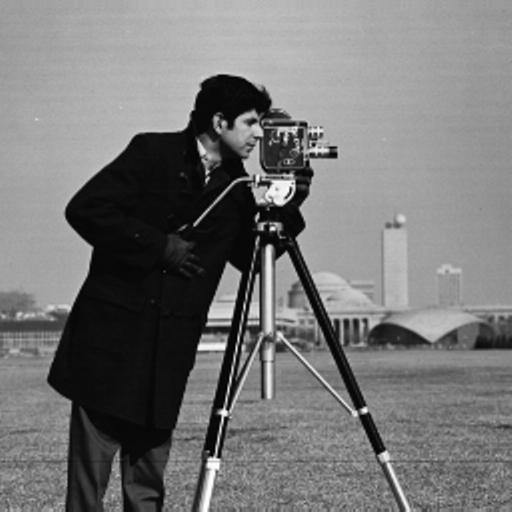

In [3]:
# ── Load image ────────────────────────────────────
image_path = "lab3_input.jpg"
img = Image.open(image_path).convert("L")

print("Image mode:", img.mode)
print("Original size:", img.size)
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [4]:
# Get the size of the image
width, height = img.size

# scaling factors
cx = 2
cy = 2
new_size = (int(width * cx), int(height * cy))

print("Original size:", (width, height))
print("Scale factors:", (cx, cy))
print("New size:", new_size)


Original size: (512, 512)
Scale factors: (2, 2)
New size: (1024, 1024)


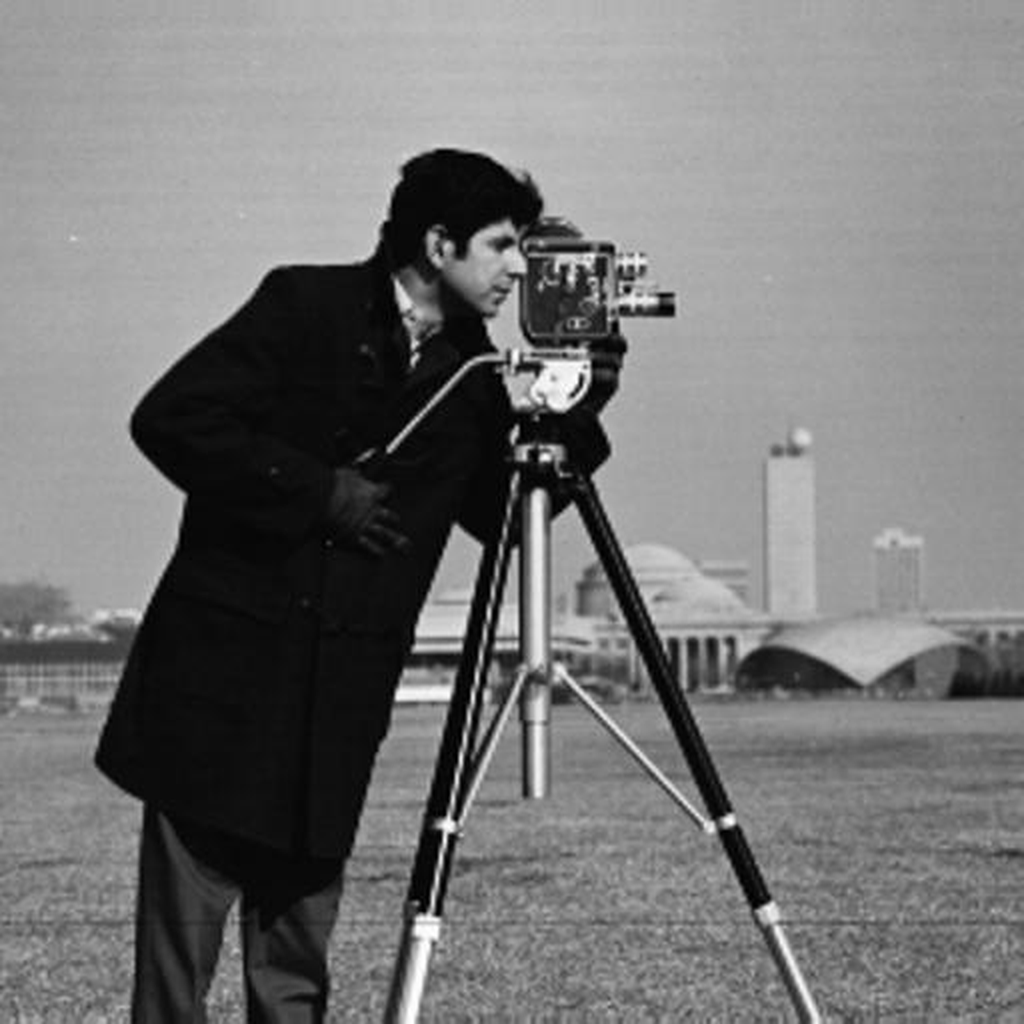

In [5]:
# ── 1. Increase size (scale ×2) ────────────────────
# Resize the image using PIL's built-in method
scaled_img = img.resize(new_size, resample=Image.Resampling.LANCZOS)

display(scaled_img)


In [6]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)
print("Saved as: task1_1_scaled.jpg")


Original size: (512, 512)
Scaled size: (1024, 1024)
Saved as: task1_1_scaled.jpg


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [7]:
# Non-uniform scaling factors: stretch horizontally only
cx = 2
cy = 1

width, height = img.size
non_uniform_size = (int(width * cx), int(height * cy))

print("Original size:", img.size)
print("Scale factors (cx, cy):", (cx, cy))
print("New size:", non_uniform_size)

Original size: (512, 512)
Scale factors (cx, cy): (2, 1)
New size: (1024, 512)


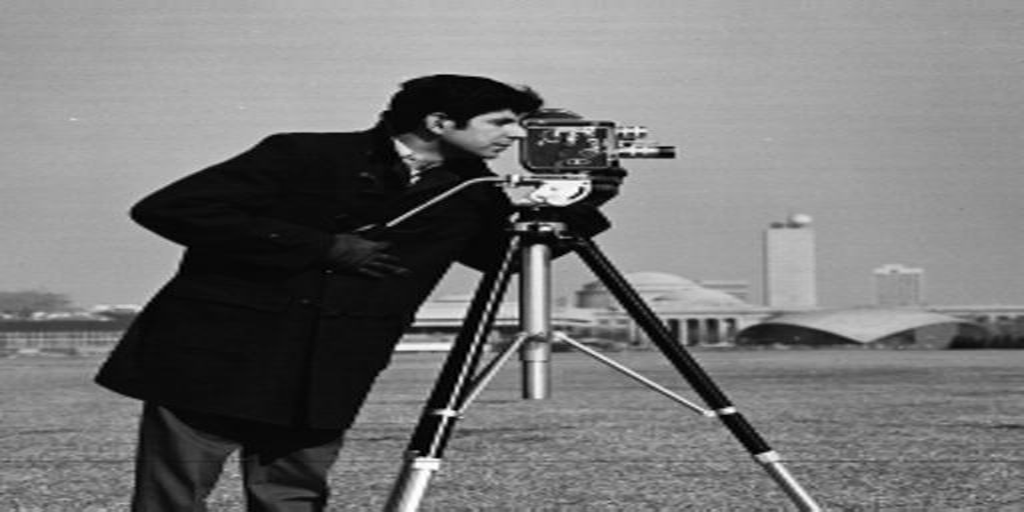

In [8]:
# Apply non-uniform scaling using LANCZOS resampling
non_uniform_img = img.resize(
    non_uniform_size,
    resample=Image.Resampling.LANCZOS
)

display(non_uniform_img)


In [9]:
# Save the non-uniformly scaled image
non_uniform_img.save("task1_1_nonuniform_scaled.jpg")

print("Original size:", img.size)
print("Non-uniform scaled size:", non_uniform_img.size)
print("Saved as: task1_1_nonuniform_scaled.jpg")

Original size: (512, 512)
Non-uniform scaled size: (1024, 512)
Saved as: task1_1_nonuniform_scaled.jpg


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated canvas size: (700, 700)
Saved as: task1_2_rotated.jpg


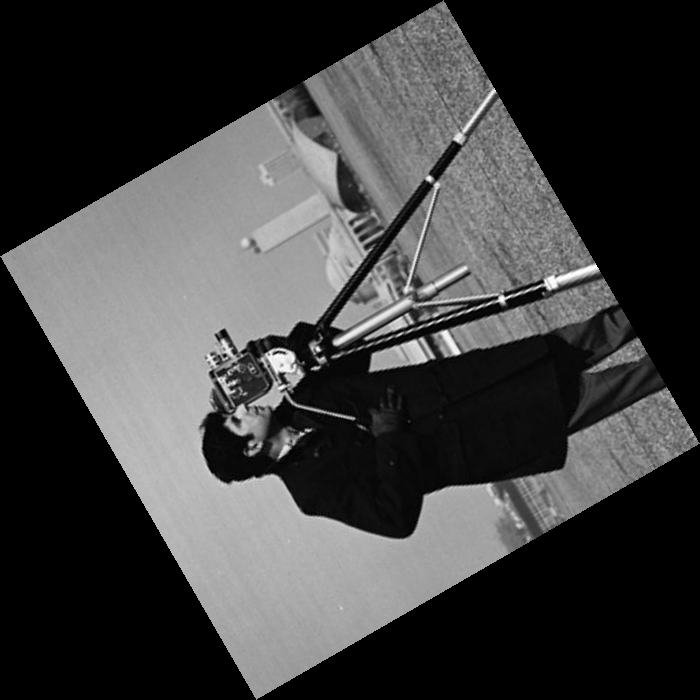

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
# expand=True enlarges the canvas so the rotated image is not cropped.
rotated_img = img.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True,
    fillcolor=0
)

# Save the rotated image (The new image name should be "task1_2_rotated.jpg")
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated canvas size:", rotated_img.size)
print("Saved as: task1_2_rotated.jpg")
display(rotated_img)

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Image dimensions:", (width, height))

Image dimensions: (512, 512)


In [12]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5
shx = shear_factor   # X-axis shear
shy = 0.0            # no Y-axis shear

# For an X-axis shear, the width must be increased by |shx| × height
new_width = int(round(width + abs(shx) * height))
new_height = height

print("Shear factor:", shear_factor)
print("Output canvas size:", (new_width, new_height))

Shear factor: 0.5
Output canvas size: (768, 512)


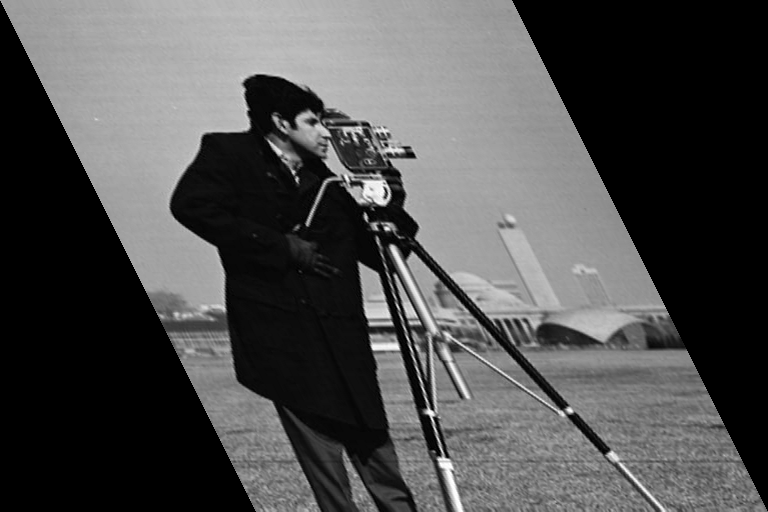

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() uses inverse mapping. For the forward X-shear
# x' = x + shx*y, the inverse mapping is x = x' - shx*y.

sheared_img = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(sheared_img)

In [14]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")

print("Original size:", img.size)
print("Sheared size:", sheared_img.size)
print("Saved as: task1_3_sheared.jpg")

Original size: (512, 512)
Sheared size: (768, 512)
Saved as: task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

Saved as: task2_1_negative_numpy.jpg


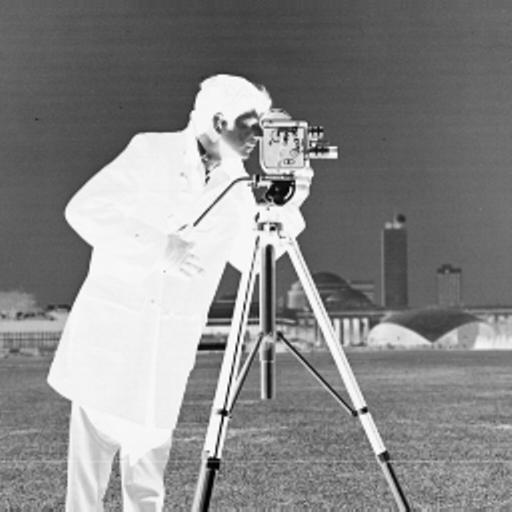

In [15]:
# ── 1. Negative ────────────────────────────────────
# Method 1: NumPy array manipulation

arr = np.asarray(img, dtype=np.uint8)
negative_np_arr = 255 - arr
negative_np_img = Image.fromarray(negative_np_arr)

negative_np_img.save("task2_1_negative_numpy.jpg")
print("Saved as: task2_1_negative_numpy.jpg")
display(negative_np_img)




Saved as: task2_1_negative_pil.jpg
Both negative methods give the same pixels: True


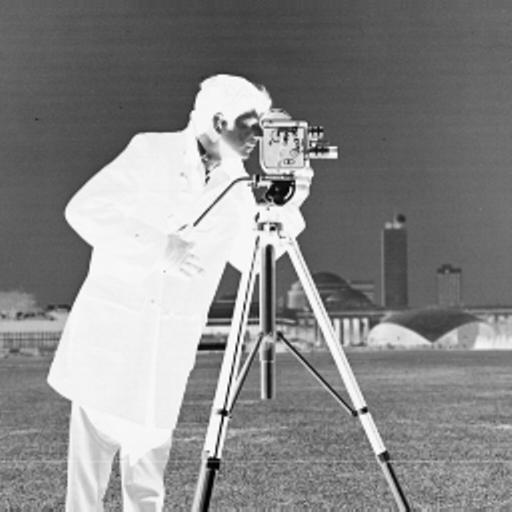

In [16]:
# Method 2: PIL's ImageOps
negative_pil_img = ImageOps.invert(img)
negative_pil_img.save("task2_1_negative_pil.jpg")

print("Saved as: task2_1_negative_pil.jpg")
print(
    "Both negative methods give the same pixels:",
    np.array_equal(np.asarray(negative_np_img), np.asarray(negative_pil_img))
)
display(negative_pil_img)

c = 45.9859
Saved as: task2_2_log.jpg


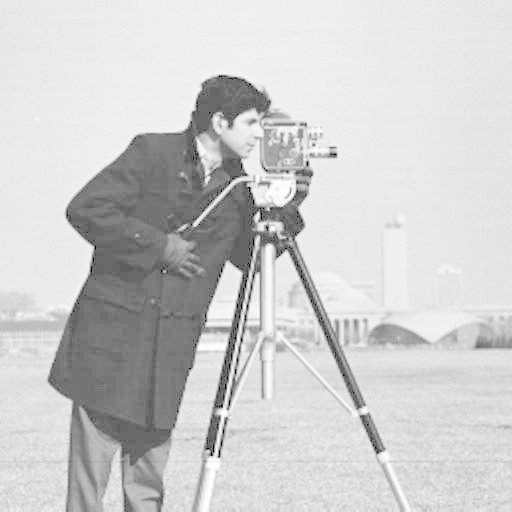

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255 / np.log1p(255)

# Convert to float BEFORE applying log1p to avoid uint8 overflow.
arr_float = np.asarray(img, dtype=np.float32)

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log1p(arr_float)
log_transformed_arr = np.clip(log_transformed_arr, 0, 255).astype(np.uint8)
log_transformed_img = Image.fromarray(log_transformed_arr)

log_transformed_img.save("task2_2_log.jpg")
print(f"c = {c:.4f}")
print("Saved as: task2_2_log.jpg")
display(log_transformed_img)

Gamma used: 0.5
Saved as: task2_3_gamma_0_5.jpg


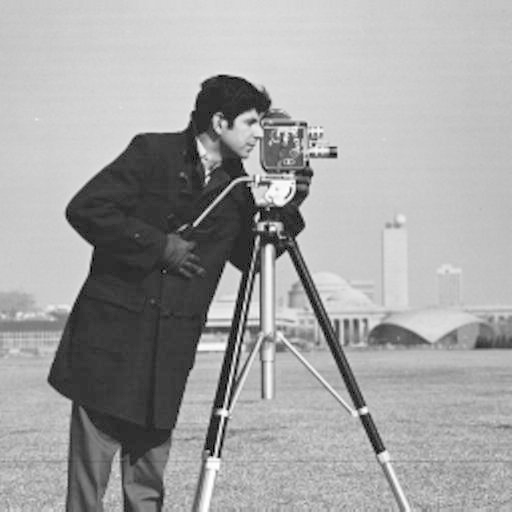

In [18]:
# ── 3. Power-law / Gamma correction ───────────────
# Formula: s = 255 * (r / 255)^gamma

arr_float = np.asarray(img, dtype=np.float32)

def gamma_correction(image_array, gamma):
    normalized = image_array / 255.0
    corrected = 255.0 * np.power(normalized, gamma)
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return Image.fromarray(corrected)

# gamma < 1 brightens; gamma > 1 darkens.
gamma = 0.5
gamma_img = gamma_correction(arr_float, gamma)
gamma_img.save("task2_3_gamma_0_5.jpg")

print("Gamma used:", gamma)
print("Saved as: task2_3_gamma_0_5.jpg")
display(gamma_img)

gamma = 0.5 -> task2_3_gamma_0_5.jpg


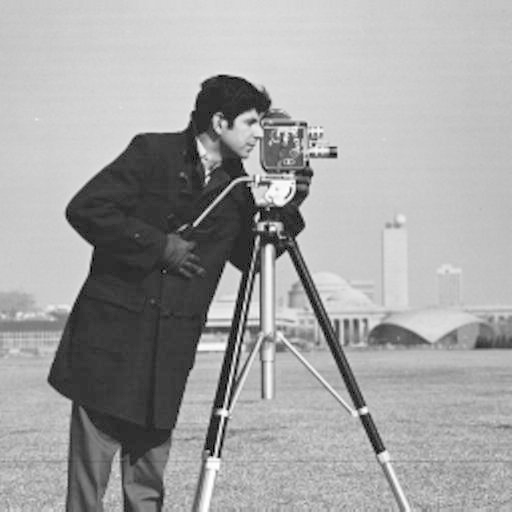

gamma = 1.0 -> task2_3_gamma_1_0.jpg


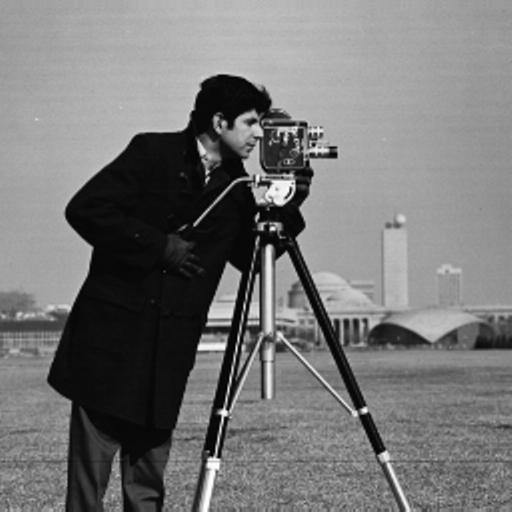

gamma = 2.0 -> task2_3_gamma_2_0.jpg


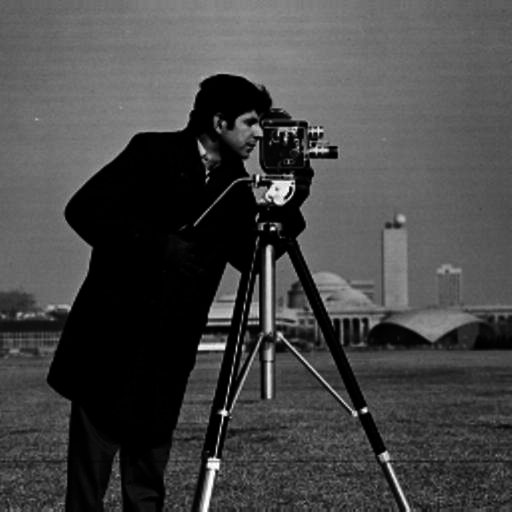

In [19]:
# Compare a few gamma values
for gamma_value in [0.5, 1.0, 2.0]:
    result = gamma_correction(arr_float, gamma_value)
    filename = f"task2_3_gamma_{str(gamma_value).replace('.', '_')}.jpg"
    result.save(filename)
    print(f"gamma = {gamma_value} -> {filename}")
    display(result)